## **Import Relevant Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Train Data

In [3]:
train = pd.read_csv("Train.csv")
train.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


# Test Data

In [4]:
test=  pd.read_csv("Test.csv")
test.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6,B
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6,A
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6,A
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6,B
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6,A


## **Data preprocessing**

In [6]:
train.columns

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='object')

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2577 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2603 non-null   object 
 5   Profession       2589 non-null   object 
 6   Work_Experience  2358 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2514 non-null   float64
 9   Var_1            2595 non-null   object 
 10  Segmentation     2627 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 225.9+ KB


In [266]:
train.describe()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
count,8068.000000,8068.000000,8068.000000,8068.000000,8068.000000,8068.000000,8068.000000,8068.000000,8068.000000,8068.000000,8068.000000
mean,463479.214551,0.547471,0.592836,43.466906,0.625434,2.746901,2.472980,0.546108,2.814824,5.147372,1.561973
std,2595.381232,0.497772,0.491336,16.711696,0.484041,2.541418,3.265248,0.741202,1.508841,1.419453,1.139029
min,458982.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,461240.750000,0.000000,0.000000,30.000000,0.000000,0.000000,0.000000,0.000000,2.000000,4.000000,1.000000
50%,463472.500000,1.000000,1.000000,40.000000,1.000000,3.000000,1.000000,0.000000,2.000000,6.000000,2.000000
75%,465744.250000,1.000000,1.000000,53.000000,1.000000,5.000000,4.000000,1.000000,4.000000,6.000000,3.000000
max,467974.000000,1.000000,1.000000,89.000000,1.000000,8.000000,14.000000,2.000000,9.000000,7.000000,3.000000


In [268]:
test.describe()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
count,2627.000000,2627.000000,2627.000000,2627.000000,2627.000000,2627.000000,2627.000000,2627.000000,2627.000000,2627.000000,2627.000000
mean,463433.918919,0.542063,0.597640,43.649791,0.618957,2.793300,2.393605,0.531785,2.789874,5.135896,1.435478
std,2618.245698,0.498322,0.490467,16.967015,0.485736,2.585091,3.200165,0.736931,1.527360,1.405365,1.211743
min,458989.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,461162.500000,0.000000,0.000000,30.000000,0.000000,0.000000,0.000000,0.000000,2.000000,4.000000,0.000000
50%,463379.000000,1.000000,1.000000,41.000000,1.000000,2.000000,1.000000,0.000000,2.000000,6.000000,1.000000
75%,465696.000000,1.000000,1.000000,53.000000,1.000000,5.000000,3.000000,1.000000,4.000000,6.000000,3.000000
max,467968.000000,1.000000,1.000000,89.000000,1.000000,8.000000,14.000000,2.000000,9.000000,7.000000,3.000000


# Visualization

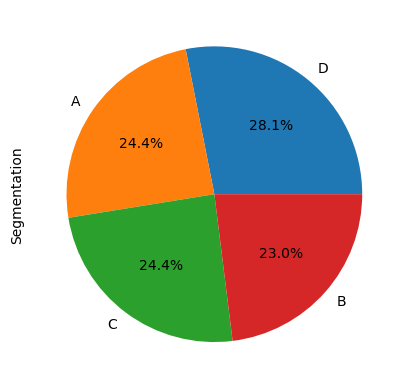

In [9]:
train['Segmentation'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.show()

This pie chart, titled "Segmentation," presents the distribution of four different segments—A, B, C, and D—using color-coded sections. 

Among these, Segment D has the largest share at 28.1%, while Segment B has the smallest at 23.0%. Pie charts like this are useful for comparing proportions within a whole and quickly identifying which categories have the most significant representation. If you’re analyzing market data, customer segments, or even budget allocations, this kind of visual helps in making informed decisions.

## **Analysis of Gender**

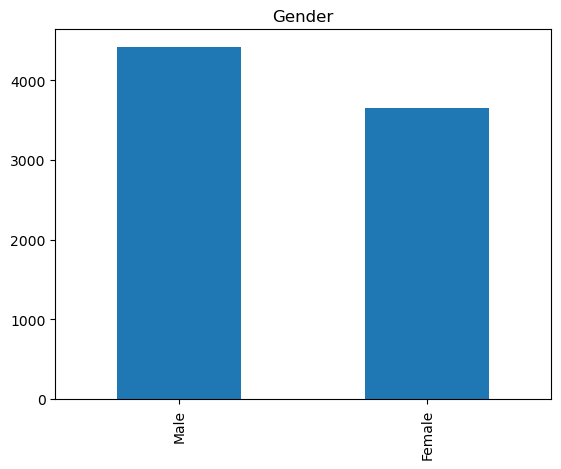

In [11]:
train['Gender'].value_counts().plot(kind='bar')
plt.title("Gender")
plt.show()

This bar graph, titled "Gender," compares the number of males and females in a given dataset.

From this, we can see that there are more males than females in this dataset. Bar graphs like this are useful for visualizing categorical comparisons clearly, whether for population studies, survey results, or business demographics.

In [12]:
train['Gender'] = train['Gender'].replace({"Male":1,"Female":0})
test["Gender"]= test["Gender"].replace({"Male":1,"Female":0})

In [13]:
train["Gender"].value_counts()

1    4417
0    3651
Name: Gender, dtype: int64

In [14]:
test["Gender"].value_counts()

1    1424
0    1203
Name: Gender, dtype: int64

In [15]:
train['Gender'].isnull().sum()

0

In [16]:
test['Gender'].isnull().sum()

0

## **Analysis of Ever_Married**

In [18]:
train['Ever_Married'].unique()

array(['No', 'Yes', nan], dtype=object)

In [19]:
train["Ever_Married"].isnull().sum()
test['Ever_Married'].isnull().sum()

50

In [20]:
train['Ever_Married']=train['Ever_Married'].replace({"Yes":1,"No":0})
test['Ever_Married']=test['Ever_Married'].replace({"Yes":1,"No":0})

In [21]:
train['Ever_Married']= train['Ever_Married'].fillna(1)
test['Ever_Married']=test['Ever_Married'].fillna(1)

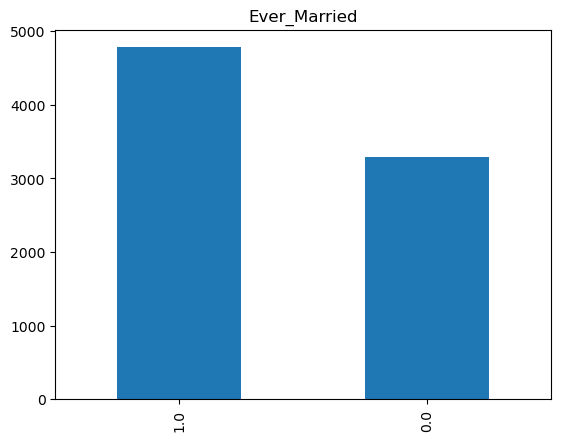

In [22]:
train['Ever_Married'].value_counts().plot(kind='bar')
plt.title('Ever_Married')
plt.show()

This bar graph, titled "Ever_Married," compares the number of individuals who have ever been married versus those who have not.

From the graph, we can see that:

This tells us that more individuals have been married compared to those who have not in the dataset. Bar graphs like this are useful for comparing categorical data at a glance, making it easy to spot trends in a population.

## **Analysis of Age**

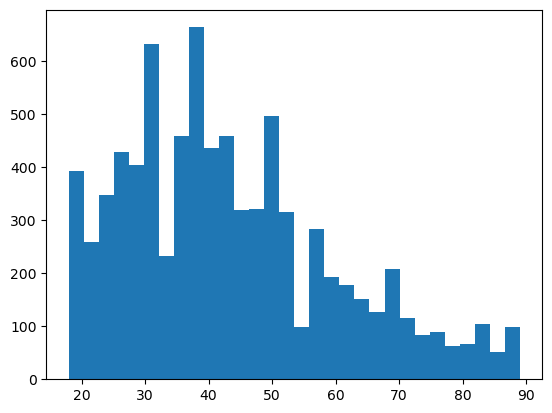

In [24]:
plt.hist(train['Age'], bins= 30)
plt.show()

This histogram displays the frequency distribution of a dataset, helping us understand how values are spread across different intervals.

Histograms like this are useful for identifying patterns, trends, and outliers in data. They help determine whether the data follows a normal distribution or if there are notable variations.

In [25]:
train["Age"].isnull().sum()
test['Age'].isnull().sum()

0

<Axes: xlabel='Age', ylabel='count'>

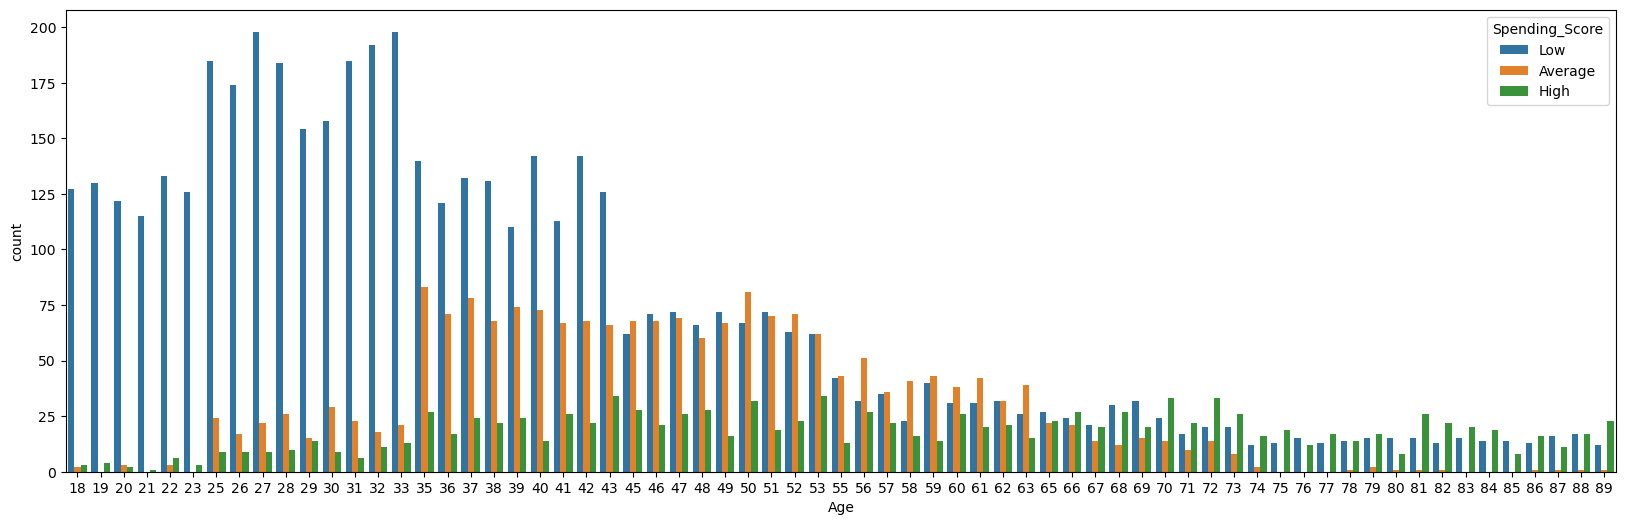

In [26]:
plt.figure(figsize=(20,6))
sns.countplot(x="Age", data=train, hue="Spending_Score")

This bar graph illustrates the distribution of spending scores across different age groups.
1. Younger individuals (18-32) mostly have low spending scores, with counts reaching up to 200.
2. Age group 33-55 displays a more varied distribution, with an increase in average spending scores.
3. Older individuals (56+) show a decrease in low spending scores, while high spending scores slightly increase.
4. Highest count of low spending scores occurs in the age range 25-32.
5. Balanced distribution between low, average, and high spending scores appears in ages 40-55.


## **Analysis of Graduated**

In [28]:
train['Graduated'].isnull().sum()

78

In [29]:
test["Graduated"].isnull().sum()

24

In [30]:
test["Graduated"]= test["Graduated"].replace({"Yes":1,"No":0})
train['Graduated']=train['Graduated'].replace({"Yes":1,"No":0})

In [31]:
test["Graduated"] = test["Graduated"].fillna(1)
train['Graduated']=train['Graduated'].fillna(1)

In [32]:
train['Graduated'].isnull().sum()

0

In [33]:
test['Graduated'].isnull().sum()

0

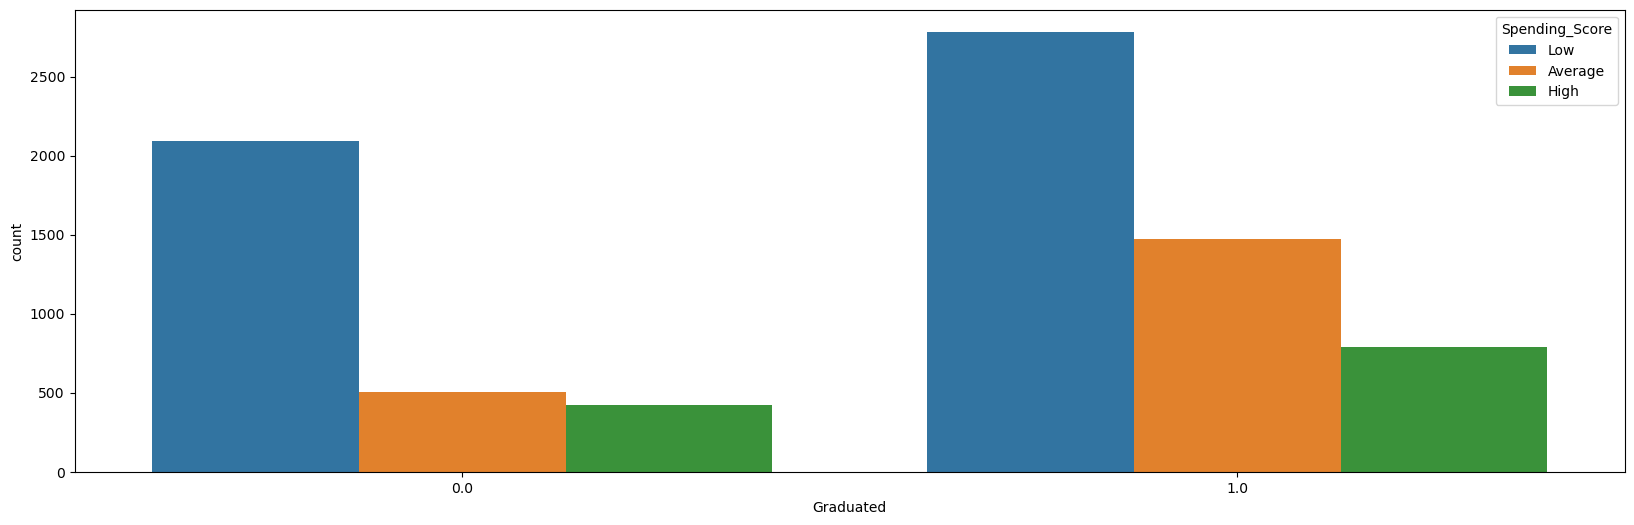

In [34]:
plt.figure(figsize=(20,6))
sns.countplot(x="Graduated", data=train, hue="Spending_Score")
plt.show()

X-axis: Represents whether individuals have graduated (0 = Not Graduated, 1 = Graduated).
Y-axis: Represents the count of individuals.
Spending score is categorized into Low (blue), Average (orange), and High (green).


## **Analysis of Profession**

In [36]:
train["Profession"].isnull().sum()

124

In [37]:
test["Profession"].isnull().sum()

38

In [38]:
train["Profession"].value_counts()

Artist           2516
Healthcare       1332
Entertainment     949
Engineer          699
Doctor            688
Lawyer            623
Executive         599
Marketing         292
Homemaker         246
Name: Profession, dtype: int64

In [39]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy="most_frequent")

In [40]:
train['Profession'] = train['Profession'].fillna(train['Profession'].mode()[0])
test['Profession'] = test['Profession'].fillna(test['Profession'].mode()[0])

In [41]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train["Profession"]=le.fit_transform(train["Profession"])
test["Profession"]= le.fit_transform(test["Profession"])

In [42]:


train["Profession"].unique()

array([5, 2, 7, 3, 0, 4, 1, 6, 8])

In [43]:
test["Profession"].unique()

array([2, 5, 0, 4, 8, 1, 7, 3, 6])

In [44]:
train["Profession"].head()

0    5
1    2
2    2
3    7
4    3
Name: Profession, dtype: int32

In [45]:
test["Profession"].head()

0    2
1    5
2    0
3    4
4    8
Name: Profession, dtype: int32

In [46]:
train["Profession"].isnull().sum()

0

In [47]:
test['Profession'].isnull().sum()

0

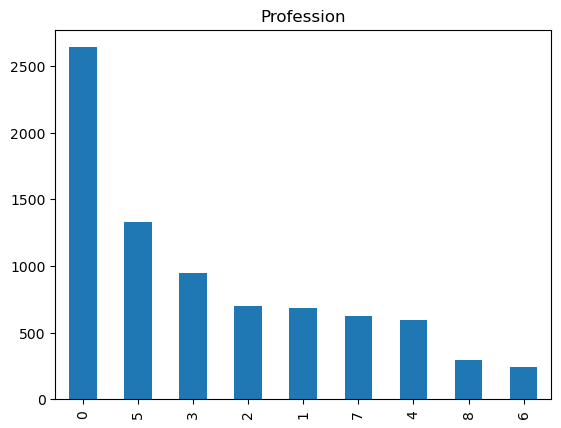

In [48]:
train["Profession"].value_counts().plot(kind='bar')
plt.title("Profession")
plt.show()

This bar graph, titled **"Profession,"** displays the distribution of individuals across different professions.

### Breakdown:
- **X-axis:** Represents different professions, labeled from **0 to 8**.
- **Y-axis:** Represents the count of individuals in each profession, ranging from **0 to 2500**.
- The **highest count** is in **profession 0**, with over **2500 individuals**.
- **Profession 5** has around **1200 individuals**.
- **Profession 3** has approximately **900 individuals**.
- The numbers **gradually decline**, with **profession 6** having the **lowest count**, roughly **300 individuals**.

### Key Insights:
- **Profession 0 dominates**, having the largest representation.
- **Professions 3 and 5** also hold a notable share.
- **Professions 6, 7, and 8** appear to have the fewest individuals.

## **Analysis of Work_Experience**

In [50]:
train['Work_Experience'].unique()

array([ 1., nan,  0.,  4.,  9., 12.,  3., 13.,  5.,  8., 14.,  7.,  2.,
        6., 10., 11.])

In [51]:
train['Work_Experience'].isnull().sum()

829

In [52]:

si_num =SimpleImputer(strategy = 'median')

In [53]:
train['Work_Experience']= si_num.fit_transform(train[['Work_Experience']])
test['Work_Experience'] = si_num.fit_transform(test[["Work_Experience"]])

In [54]:
train['Work_Experience'].isnull().sum()

0

In [55]:
test['Work_Experience'].isnull().sum()

0

In [56]:
train.columns

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='object')

<Axes: xlabel='Work_Experience', ylabel='count'>

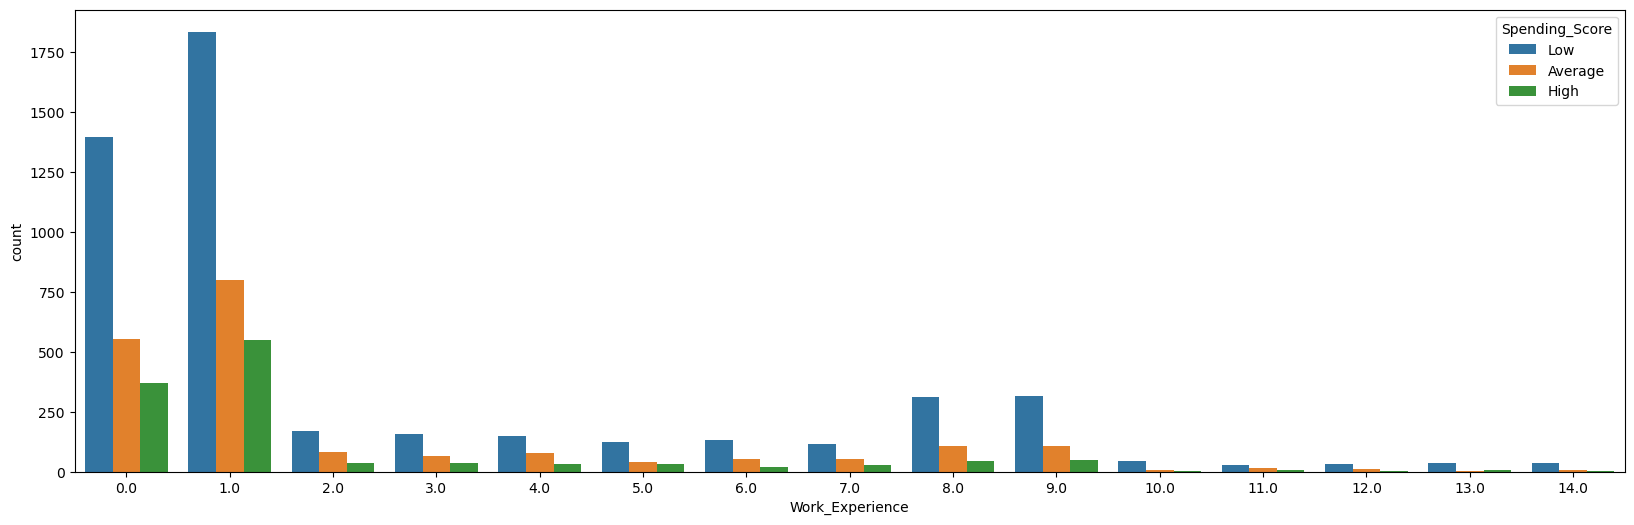

In [57]:
plt.figure(figsize=(20,6))
sns.countplot(x="Work_Experience", data=train, hue="Spending_Score")

This bar graph illustrates the **distribution of spending scores** across different levels of **work experience**.

### **Graph Breakdown**
- **X-axis:** Represents **work experience in years**, ranging from **0 to 14**.
- **Y-axis:** Represents the **count of individuals**.
- **Spending scores are color-coded:**  
  - **Low (blue)**  
  - **Average (orange)**  
  - **High (green)**  

## **Analysis of Spending Score**

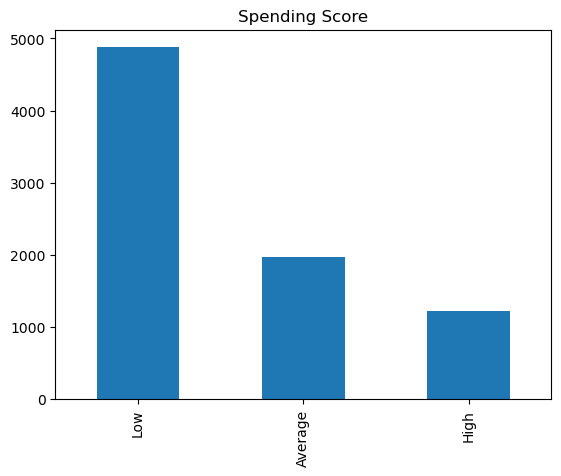

In [59]:
train['Spending_Score'].value_counts().plot(kind = "bar")
plt.title("Spending Score")
plt.show()

This bar chart, titled **"Spending Score,"** represents the distribution of individuals based on their spending score.

### Breakdown:
- **X-axis:** Displays three spending categories: **Low, Average, and High.**
- **Y-axis:** Represents the **count of individuals,** ranging from **0 to 5000.**
- **The Low category dominates,** with a count reaching **approximately 5000.**
- **The Average category follows,** with a count of **around 2000.**
- **The High spending category has the lowest count,** approximately **1000 individuals.**

### Key Insights:
- **Most individuals fall into the Low spending category,** suggesting a preference for controlled or cautious spending.
- **Average spending is noticeably lower,** but still holds a significant number.
- **High spending is the least common,** indicating that fewer individuals engage in high expenditures.

This graph helps in analyzing consumer behavior, spending patterns, and financial distribution trends.

In [60]:
train['Spending_Score'].isnull().sum()

0

In [61]:

test['Spending_Score'].isnull().sum()

0

In [62]:
train['Spending_Score'] = train['Spending_Score'].replace({"Low":0,"Average":1,"High":2})

test['Spending_Score'] = test['Spending_Score'].replace({"Low":0,"Average":1,"High":2})

In [63]:

test['Spending_Score'].unique()

array([0, 1, 2], dtype=int64)

## **Analysis of Family_Size**

In [65]:
train["Family_Size"].unique()

array([ 4.,  3.,  1.,  2.,  6., nan,  5.,  8.,  7.,  9.])

In [66]:
train['Family_Size'].isnull().sum()

335

In [67]:
test['Family_Size'].isnull().sum()

113

In [68]:
train['Family_Size']= train['Family_Size'].fillna(2)
test['Family_Size']=test['Family_Size'].fillna(2)

In [69]:
train['Family_Size'].isnull().sum()

0

<Axes: xlabel='Family_Size', ylabel='count'>

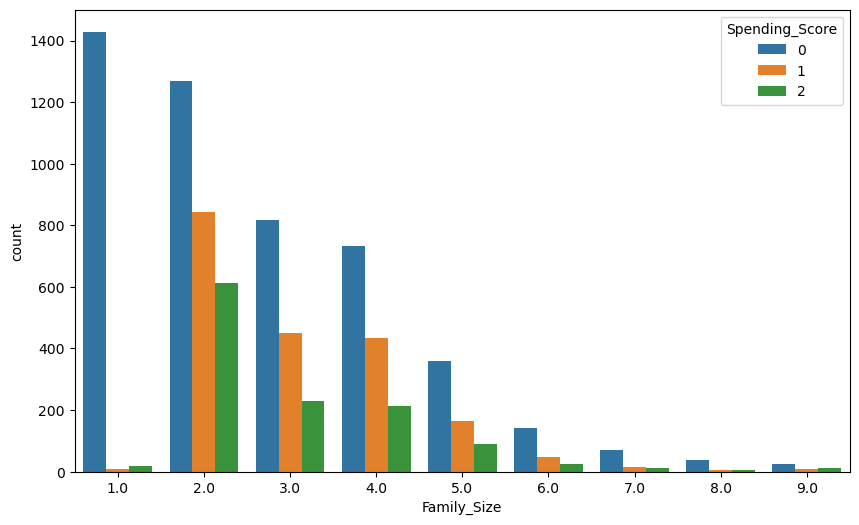

In [70]:
plt.figure(figsize=(10,6))
sns.countplot(x="Family_Size", data=train, hue="Spending_Score")

This **pie chart**, titled **"Segmentation,"** visually represents the distribution of four different segments—**A, B, C, and D**—using color-coded sections. Here’s the breakdown:

- **Segment A (orange):** 24.4%  
- **Segment B (red):** 23.0%  
- **Segment C (green):** 24.4%  
- **Segment D (blue):** 28.1%  

Among these, **Segment D** has the largest share at **28.1%**, while **Segment B** has the smallest at **23.0%**. Pie charts like this help compare proportions within a whole, making it easy to identify the most significant contributors. 

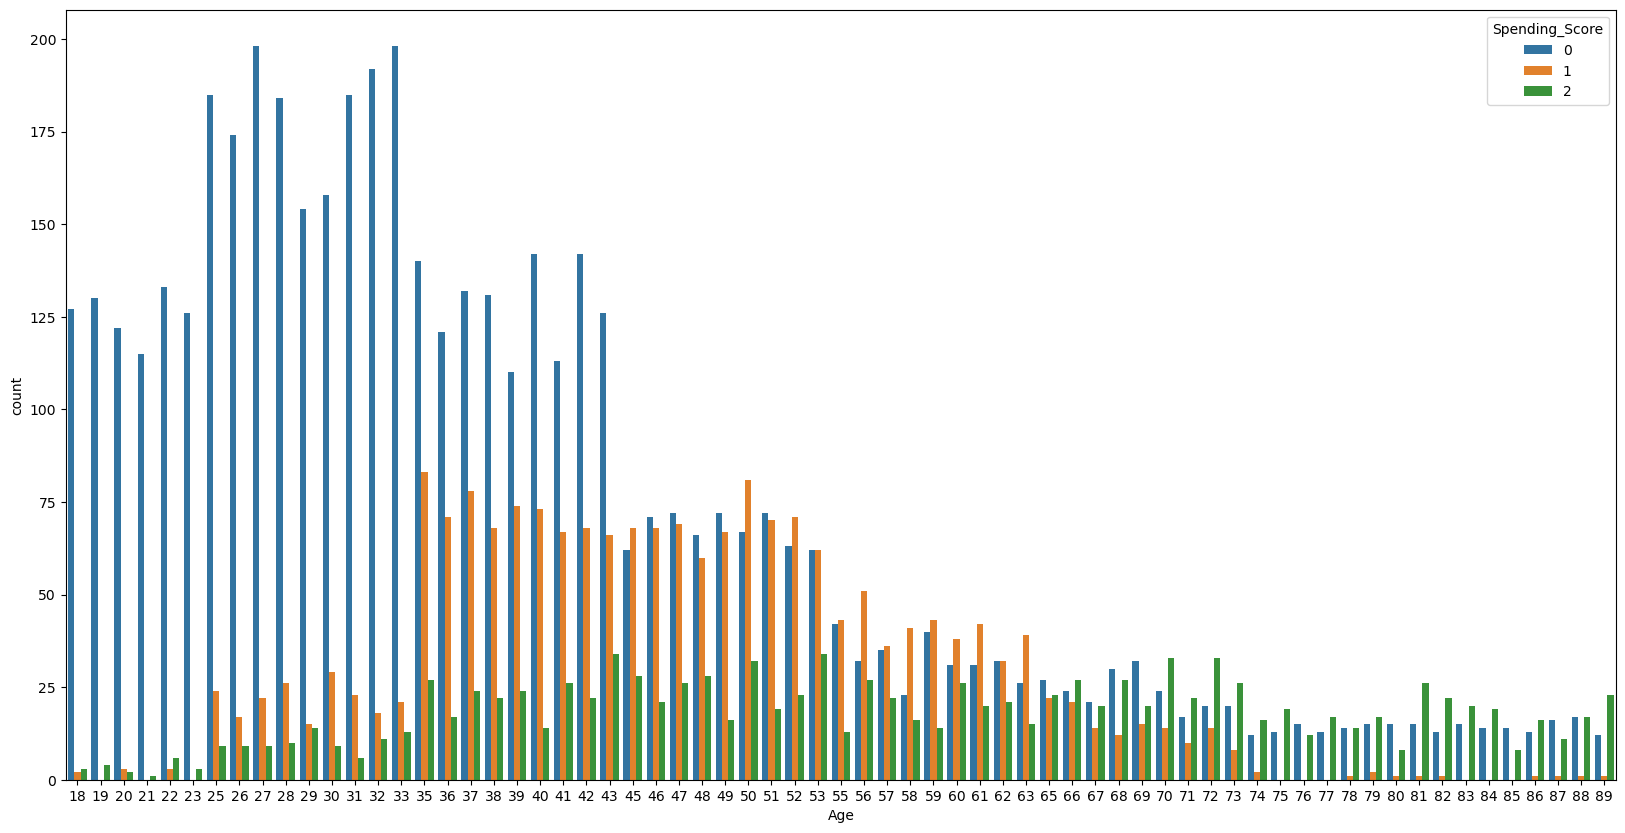

In [71]:
plt.figure(figsize=(20,10))
sns.countplot(x="Age", data=train, hue="Spending_Score")
plt.show()

Here in this bar graph, displays the **count of individuals** categorized by **age and spending score**.

### **Graph Breakdown**
- **X-axis:** Represents **age**, ranging from **18 to 89 years**.
- **Y-axis:** Represents the **count of individuals**.
- **Spending score is color-coded:**  
  - **Blue (0)** – Individuals with a **low spending score**.  
  - **Orange (1)** – Individuals with an **average spending score**.  
  - **Green (2)** – Individuals with a **high spending score**.  

### **Key Observations**
1. **Younger individuals (ages 18-32)** tend to have a **low spending score**, with counts reaching up to **200**.
2. **Age group 33-55** shows a **more balanced** distribution, with increased **average and high spending scores**.
3. **Older individuals (56+)** have **lower counts overall**, but spending scores are **more evenly distributed**.


## **Analysis of Var_1**

In [73]:
train['Var_1'].unique()

array(['Cat_4', 'Cat_6', 'Cat_7', 'Cat_3', 'Cat_1', 'Cat_2', nan, 'Cat_5'],
      dtype=object)

In [74]:
train['Var_1'].isnull().sum()

76

In [75]:

test["Var_1"].isnull().sum()

32

In [76]:
train['Var_1'] = train['Var_1'].fillna(6)
test['Var_1']= test['Var_1'].fillna(6)

In [77]:
train['Var_1'].unique()

array(['Cat_4', 'Cat_6', 'Cat_7', 'Cat_3', 'Cat_1', 'Cat_2', 6, 'Cat_5'],
      dtype=object)

In [78]:
train['Var_1'] = train['Var_1'].replace({'Cat_1':1,'Cat_2':2,'Cat_3':3,'Cat_4':4,'Cat_5':5,'Cat_6':6,'Cat_7':7})
test['Var_1'] = test['Var_1'].replace({'Cat_1':1,'Cat_2':2,'Cat_3':3,'Cat_4':4,'Cat_5':5,'Cat_6':6,'Cat_7':7})


In [79]:
train['Var_1'].unique()

array([4, 6, 7, 3, 1, 2, 5], dtype=int64)

In [80]:
train['Var_1'].isnull().sum()

0

## **Analysis of Segmentation**

In [82]:
train['Segmentation'].isnull().sum()

0

In [83]:
test['Segmentation'].isnull().sum()

0

In [84]:
train['Segmentation']= le.fit_transform(train['Segmentation'])
test['Segmentation']= le.fit_transform(test['Segmentation'])

In [85]:
train['Segmentation'].unique()

array([3, 0, 1, 2])

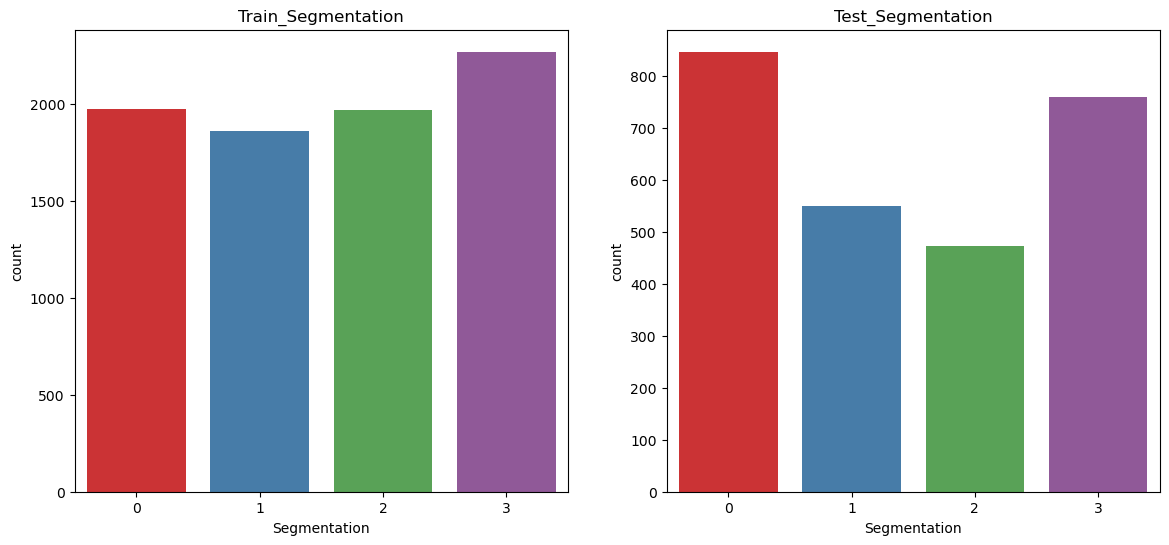

In [86]:
plt.figure(figsize =(14,6))
plt.subplot(1,2,1)
sns.countplot(x=train['Segmentation'],palette='Set1')
plt.title('Train_Segmentation')
plt.subplot(1,2,2)
sns.countplot(x=test['Segmentation'],palette='Set1')
plt.title('Test_Segmentation')
plt.show()

**two bar graphs** comparing segmentation distributions in training and testing datasets.

### **Graph Breakdown**
- **Left Graph: "Train_Segmentation"**
  - Displays the segmentation distribution in the training dataset.
  - The **count for each segmentation (0, 1, 2, 3) is roughly similar**, all slightly above **2000 individuals**.

- **Right Graph: "Test_Segmentation"**
  - Shows segmentation distribution in the test dataset.
  - **Segment 0** has **slightly above 800 individuals**.
  - **Segment 1 and Segment 2** both have **slightly below 600 individuals**.
  - **Segment 3** has **slightly above 700 individuals**.

### **Key Insights**
- The **training dataset** has a more **balanced representation** across segmentation categories.
- The **test dataset** has smaller sample sizes, with **Segment 1 and Segment 2 appearing slightly underrepresented**.
- This comparison helps **evaluate whether the training data properly reflects the test data**, ensuring a fair assessment in machine learning models.

## **Analysis of Features Engineering**

In [88]:
train.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,1,0.0,22,0.0,5,1.0,0,4.0,4,3
1,462643,0,1.0,38,1.0,2,1.0,1,3.0,4,0
2,466315,0,1.0,67,1.0,2,1.0,0,1.0,6,1
3,461735,1,1.0,67,1.0,7,0.0,2,2.0,6,1
4,462669,0,1.0,40,1.0,3,1.0,2,6.0,6,0


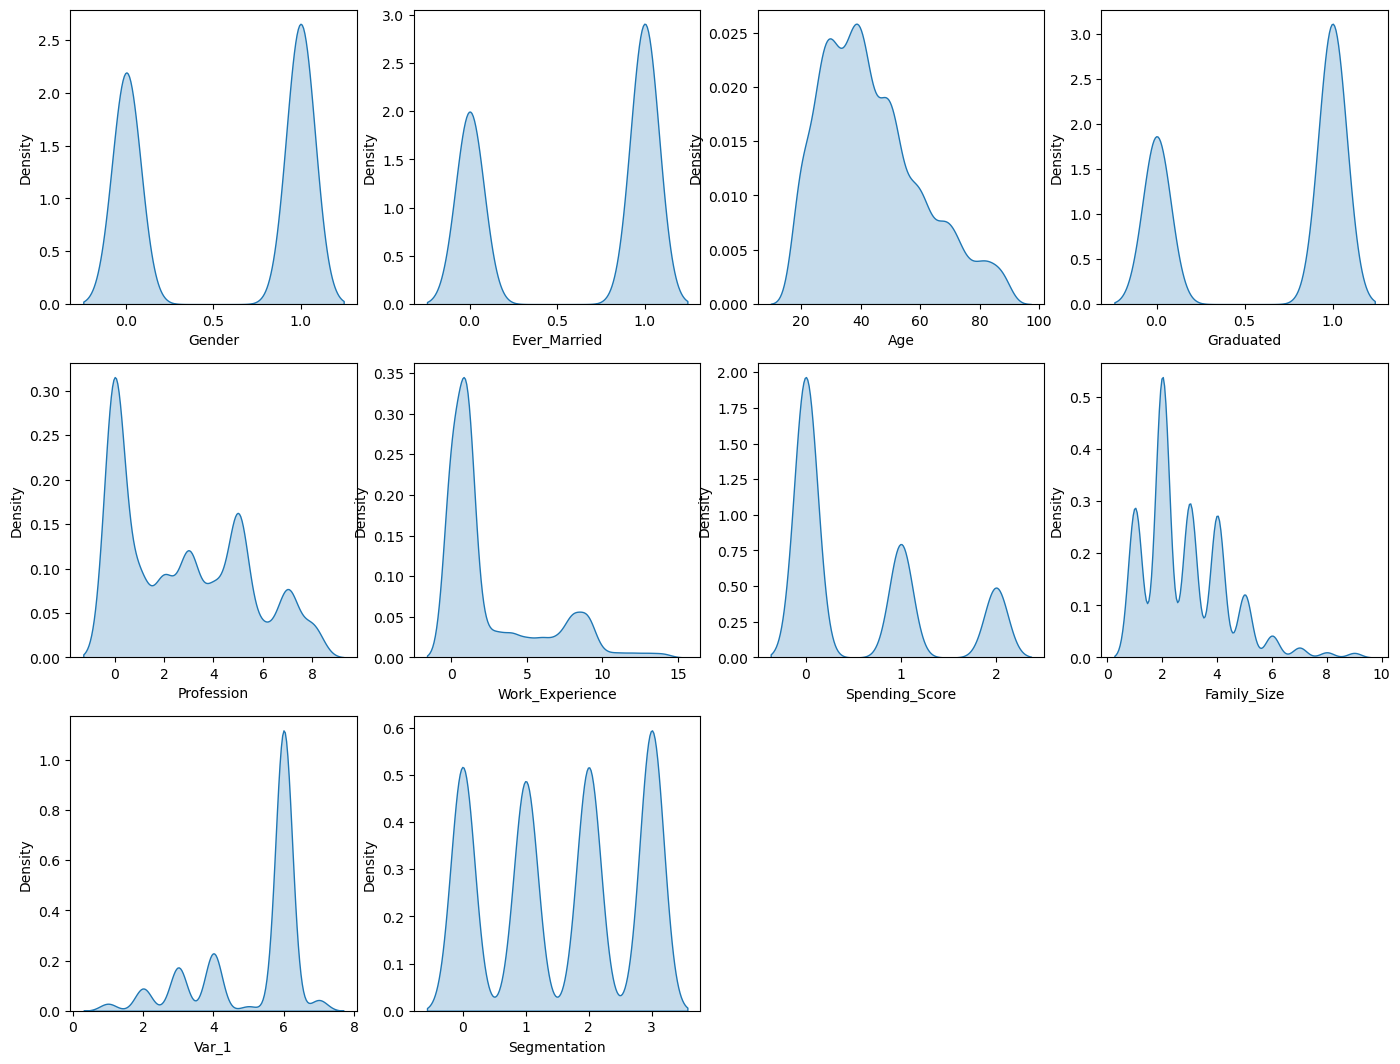

In [89]:
plt.figure(figsize=(17,13))
i=1
for col in train.iloc[:,1:]:
  plt.subplot(3,4,i)
  sns.kdeplot(train[col],fill =True)
  i+=1
plt.show()

This **density plots** for various variables, each illustrating the distribution of data points within a dataset.

### **The Graph Shows**:
- The **x-axis** represents the values of each variable.
- The **y-axis** represents **density**, showing how frequently certain values occur.
- Each plot corresponds to a different variable, including:
  - **Gender**
  - **Ever Married**
  - **Age**
  - **Graduated**
  - **Profession**
  - **Work Experience**
  - **Spending Score**
  - **Family Size**
  - **Var_1**
  - **Segmentation**

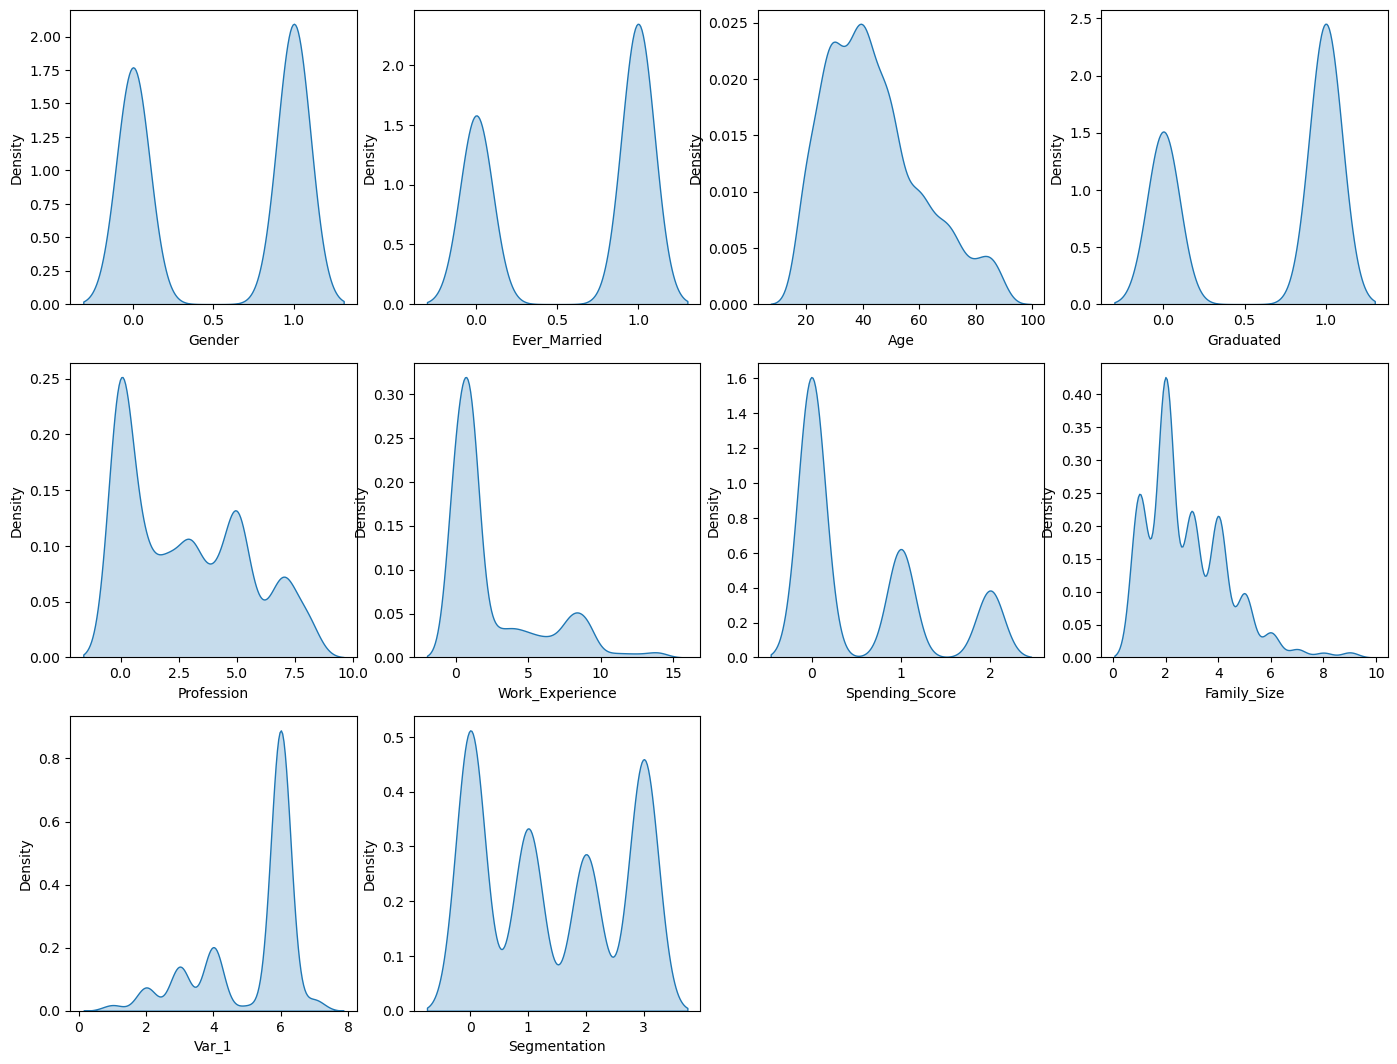

In [90]:
plt.figure(figsize=(17,13))
i=1
for col in test.iloc[:,1:]:
  plt.subplot(3,4,i)
  sns.kdeplot(test[col],fill =True)
  i+=1
plt.show()

This image contains a series of **density plots** for various variables, illustrating their distribution patterns.

### **Graph Breakdown**
- **X-axis**: Represents the values of each variable.
- **Y-axis**: Represents the **density**, showing how frequently specific values appear.
### **What This Means**
These density plots offer **valuable insights** into trends within the dataset, helping in **categorization, segmentation, and predictive modeling**.

## **Outliers**

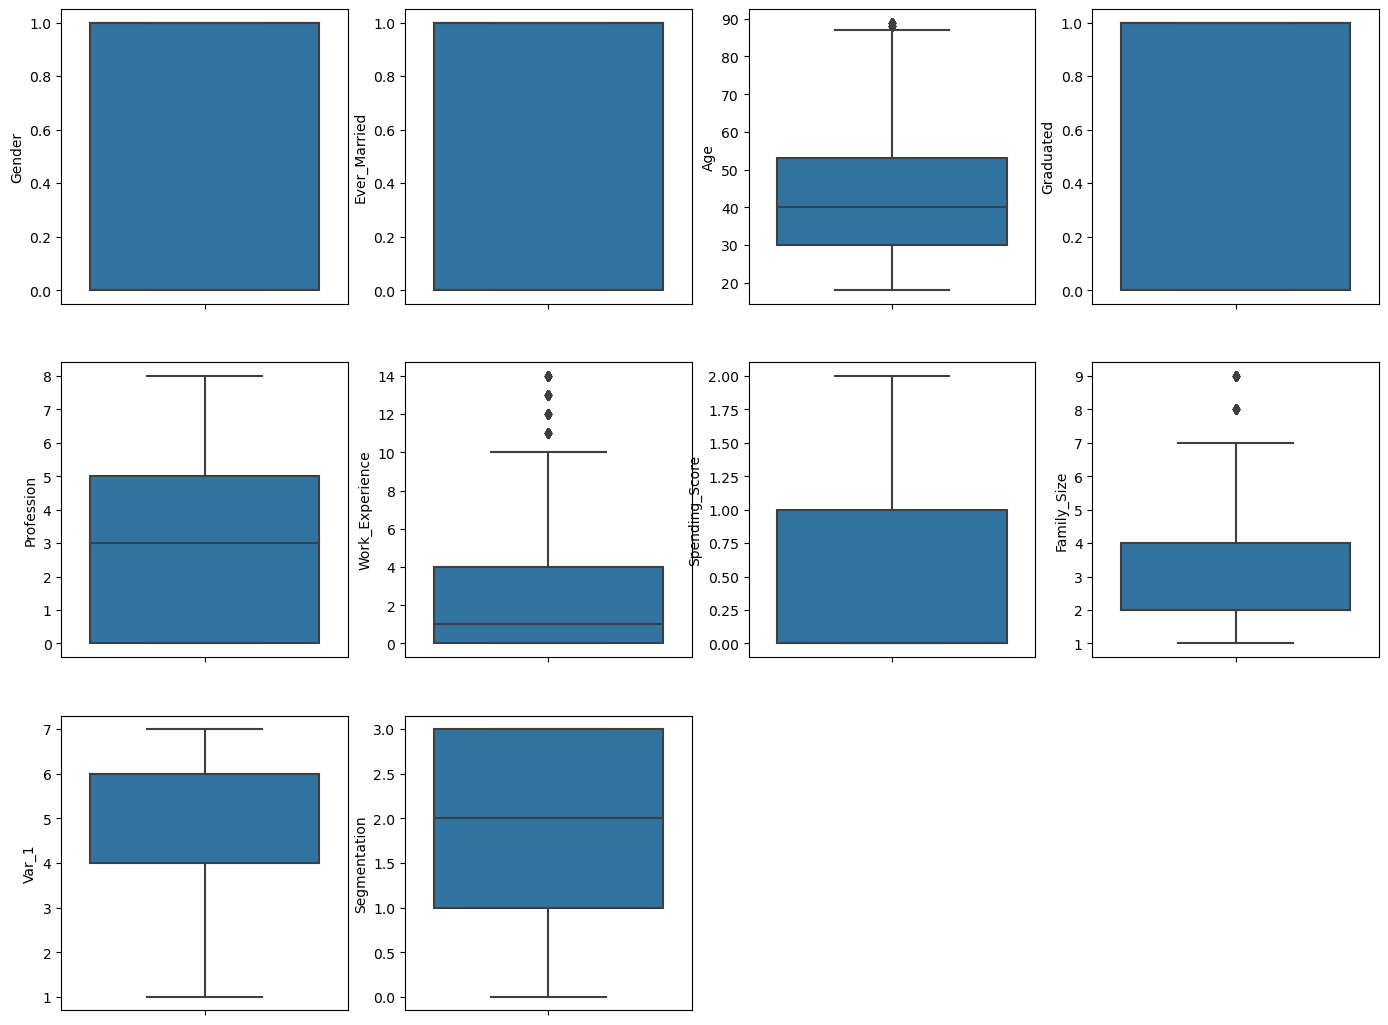

In [92]:
plt.figure(figsize=(17,13))
i=1
for col in train.iloc[:,1:]:
  plt.subplot(3,4,i)
  sns.boxplot(y= train[col],data=train)
  i+=1
plt.show()

This image contains **ten box plots**, each representing the distribution of different variables in a dataset.
### **Key Insights**
- **Constant Variables**: The box plots for **Gender, Ever_Married, and Graduated** appear static, indicating little to no variability in these categories.
- **Age Distribution**: The **median age is around 30**, with a range spanning from **20 to 90** and an **outlier above 90**.
- **Profession Variation**: The range is from **1 to 8**, with a **median close to 4**.
- **Work Experience Trends**: The **median is around 2 years**, but there are **several outliers above 10 years**.
- **Spending Score Differences**: This variable ranges from **0 to 2**, with a **median near 0.75**.
- **Family Size Spread**: The range extends from **1 to 9**, with a **median close to 3** and **outliers above 8**.
- **Other Variables**: **Var_1 spans 1 to 7 (median ~4), and Segmentation ranges from 1 to 3 (median ~2.5).**

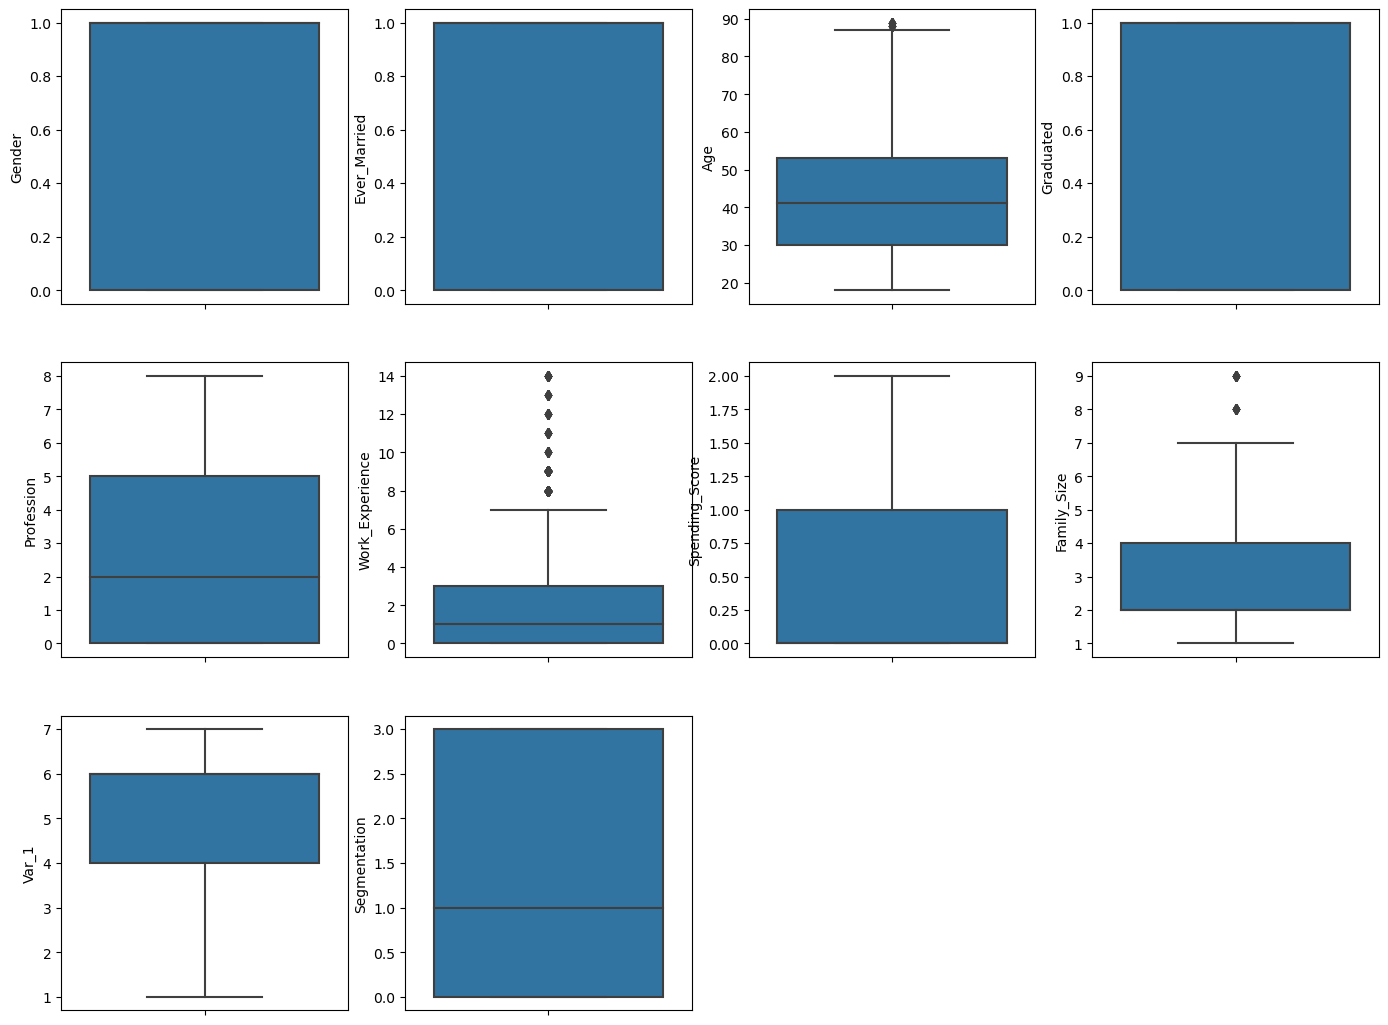

In [93]:
plt.figure(figsize=(17,13))
i=1
for col in test.iloc[:,1:]:
  plt.subplot(3,4,i)
  sns.boxplot(y= test[col],data=test)
  i+=1
plt.show()

This image contains **box plots** representing the distribution of data across multiple variables. Box plots are useful for understanding the spread and skewness of data, as well as identifying outliers.

### **Notable Insights**
- **Categorical variables** like Gender, Ever Married, Graduated, and Segmentation show limited variability.
- **Age and Work Experience** display a **wide spread** with noticeable **outliers**.
- **Family Size** has two distinct **outliers**, suggesting some individuals have exceptionally large families.
- **Profession, Spending Score, and Var_1** follow a more typical distribution without extreme values.

###  **Analysis of Behavioral Segmentation**

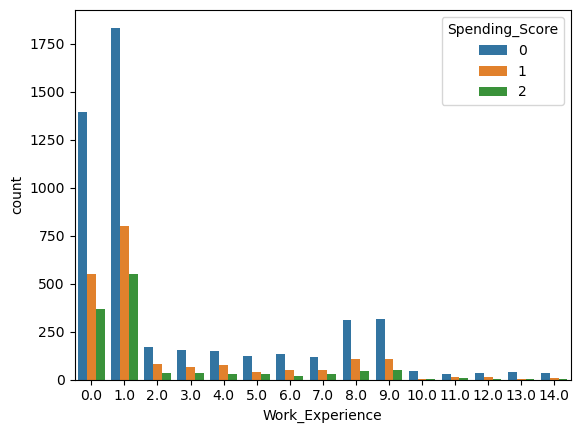

In [95]:
sns.countplot(x="Work_Experience", data=train, hue="Spending_Score")
plt.show()

This **bar plot** illustrates the distribution of **work experience** across different **spending scores**.

### **Key Insights**
1. **Individuals with 0 years of work experience**:
   - The largest group, with **spending score 0 (blue) dominating**.
   - Suggests that newcomers in the workforce **tend to spend less**.

2. **Individuals with 1 year of work experience**:
   - The highest count belongs to **spending score 1 (orange)**.
   - Indicates that after gaining a year of experience, spending habits begin to change.

3. **Individuals with 2 years of work experience**:
   - **Spending score 2 (green)** appears most frequently.
   - This could mean **early-career professionals** with slight stability **are willing to spend more**.

4. **Work experience beyond 2 years**:
   - The overall count **gradually declines** as experience increases.
   - Spending score **distribution varies more** across different experience levels.

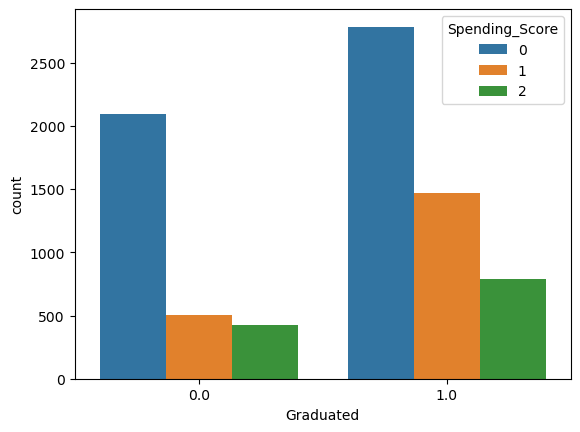

In [96]:
sns.countplot(x="Graduated", data=train, hue="Spending_Score")
plt.show()

This **bar chart** illustrates the **count of individuals** based on their **graduation status and spending score**.

### **Key Insights**
1. Among **non-graduates (0.0)**:
   - The **majority have a low spending score (blue bar)**.
   - Fewer individuals fall into **the average and high spending score categories**.

2. Among **graduates (1.0)**:
   - The **low spending score group is still the largest**, but **overall counts are higher** across all spending categories.
   - Graduates show a **slightly more balanced distribution** between low, average, and high spending scores.

This graph helps us understand how **graduation status relates to spending behavior**. Graduated individuals tend to have higher representation across all spending categories, possibly indicating **better financial stability, employment opportunities, or purchasing power**.


## **Features Selection**

In [98]:
X_train = train.drop(['ID','Segmentation'],axis=1)
y_train = train['Segmentation']

In [99]:
X_test=test.drop(['ID','Segmentation'],axis = 1)
y_test = test['Segmentation']

In [100]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((8068, 9), (8068,), (2627, 9), (2627,))

In [101]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [102]:
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),columns = X_train.columns)
X_test_scaled = pd.DataFrame(scaler.fit_transform(X_test),columns = X_test.columns)

In [103]:
X_train_scaled.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,1.0,0.0,0.056338,0.0,0.625,0.071429,0.0,0.375,0.500000
1,0.0,1.0,0.281690,1.0,0.250,0.071429,0.5,0.250,0.500000
2,0.0,1.0,0.690141,1.0,0.250,0.071429,0.0,0.000,0.833333
3,1.0,1.0,0.690141,1.0,0.875,0.000000,1.0,0.125,0.833333
4,0.0,1.0,0.309859,1.0,0.375,0.071429,1.0,0.625,0.833333


In [104]:
X_test_scaled.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,0.0,1.0,0.253521,1.0,0.250,0.000000,0.0,0.000,0.833333
1,1.0,1.0,0.267606,1.0,0.625,0.571429,0.5,0.375,0.833333
2,0.0,1.0,0.718310,0.0,0.000,0.000000,0.0,0.000,0.833333
3,1.0,1.0,0.577465,0.0,0.500,0.785714,1.0,0.125,0.833333
4,0.0,0.0,0.014085,0.0,1.000,0.071429,0.0,0.375,0.833333


## **KMeans Model**

In [106]:
from sklearn.cluster import KMeans


### **Elbow Method**

In [108]:
Wcss = []
for i in range(1,11):
  model =KMeans(n_clusters = i,random_state=0)
  model.fit(X_train_scaled)
  Wcss.append(model.inertia_)
Wcss

C:\Users\prate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\prate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\prate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\prate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of

[9382.620432492997,
 6769.670844681228,
 5612.146259270837,
 4714.72653560099,
 4023.6516205303656,
 3605.5758484338567,
 3206.441521388144,
 3016.4008019163703,
 2656.80090435739,
 2506.7068953885096]

Text(0, 0.5, 'WCSS')

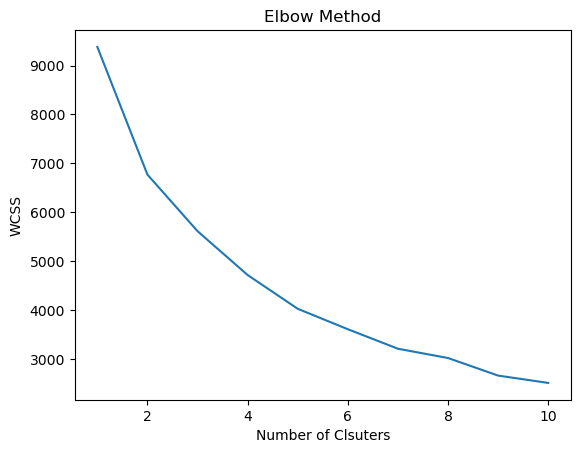

In [109]:
plt.plot(range(1,11),Wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clsuters")
plt.ylabel("WCSS")

This **line graph**, titled **"Elbow Method,"** helps determine the optimal number of clusters for a dataset when using clustering algorithms like **k-means**.

### **Graph Breakdown**
- **X-axis**: Represents the **number of clusters**, ranging from **1 to 10**.
- **Y-axis**: Represents **WCSS** (**Within-Cluster Sum of Squares**), which measures the compactness of clusters.
- The **line starts high**, around **9000 WCSS for 1 cluster**, and **steadily decreases** as the number of clusters increases.
- There is a **visible bend (elbow) around 3 to 4 clusters**, meaning that **this point represents the optimal number of clusters**.

This method helps **choose the right number of clusters**—avoiding **too few (which would mix different groups)** and **too many (which could overcomplicate the model)**.


In [110]:
Wcss = []
for i in range(1,11):
  model =KMeans(n_clusters = i,random_state=0)
  model.fit(X_test_scaled)
  Wcss.append(model.inertia_)
Wcss

C:\Users\prate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\prate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\prate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\prate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of

[3061.0685587250073,
 2219.5018730422653,
 1837.017612432897,
 1535.3698602930608,
 1307.105445643247,
 1192.6730685114046,
 1048.3591409669543,
 933.926763835112,
 862.5120201107113,
 817.9287580371893]

Text(0, 0.5, 'WCSS')

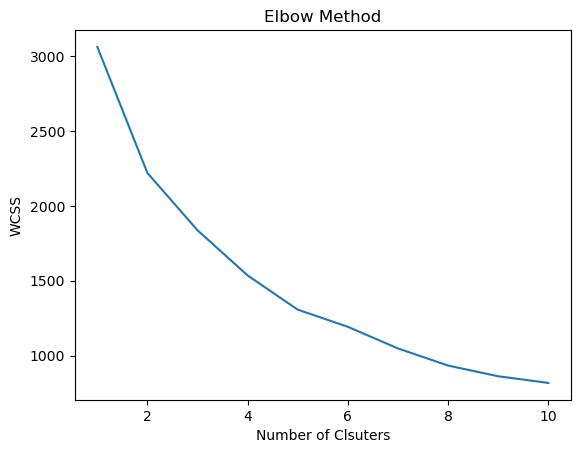

In [111]:
plt.plot(range(1,11),Wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clsuters")
plt.ylabel("WCSS")

This method, **"Elbow Method,"** helps to determine the optimal number of clusters for a dataset using **Within-Cluster Sum of Squares (WCSS).**  

### **Key Insight**  
The **elbow point** is where **adding more clusters no longer provides a significant reduction in WCSS**. This number is often chosen as the **best cluster count** for segmentation, helping ensure groups are neither **too few nor too many**.

In [112]:
from sklearn.cluster import KMeans
model= KMeans(n_clusters=3,random_state=0)
model.fit(X_train_scaled)

C:\Users\prate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=3, random_state=0)

## **Predict on train Data**

In [114]:
train_pred = model.predict(X_train_scaled)

In [115]:
train_pred[:100]

array([1, 0, 0, 2, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 0, 1, 1, 1, 2, 0, 2, 1,
       2, 1, 0, 2, 1, 2, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 2, 1, 1, 1, 0,
       2, 0, 2, 1, 1, 1, 0, 0, 2, 0, 2, 2, 1, 1, 0, 2, 2, 2, 2, 2, 2, 1,
       2, 1, 2, 0, 2, 0, 0, 1, 2, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 1, 2, 0,
       1, 2, 1, 0, 0, 2, 2, 2, 1, 2, 2, 2])

In [116]:
y_train[:100].values

array([3, 0, 1, 1, 0, 2, 2, 3, 3, 2, 0, 3, 3, 0, 1, 2, 3, 1, 1, 2, 0, 3,
       0, 1, 1, 2, 0, 2, 1, 2, 2, 0, 3, 3, 3, 3, 3, 3, 0, 2, 1, 3, 0, 2,
       0, 0, 1, 0, 3, 0, 1, 2, 0, 2, 0, 1, 3, 3, 2, 3, 2, 2, 3, 0, 0, 0,
       0, 0, 1, 0, 3, 0, 1, 3, 2, 1, 3, 0, 2, 3, 2, 3, 0, 1, 0, 3, 2, 2,
       3, 3, 1, 2, 2, 3, 1, 3, 3, 2, 2, 3])

In [117]:
X_train_scaled_new = X_train_scaled.copy()

In [118]:
X_train_scaled_new['Old_Target_Label'] = y_train
X_train_scaled_new['New_Target_Label'] = train_pred

In [119]:
X_train_scaled_new.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Old_Target_Label,New_Target_Label
0,1.0,0.0,0.056338,0.0,0.625,0.071429,0.0,0.375,0.500000,3,1
1,0.0,1.0,0.281690,1.0,0.250,0.071429,0.5,0.250,0.500000,0,0
2,0.0,1.0,0.690141,1.0,0.250,0.071429,0.0,0.000,0.833333,1,0
3,1.0,1.0,0.690141,1.0,0.875,0.000000,1.0,0.125,0.833333,1,2
4,0.0,1.0,0.309859,1.0,0.375,0.071429,1.0,0.625,0.833333,0,0


In [120]:
X_train_scaled_new['Old_Target_Label'].value_counts()

3    2268
0    1972
2    1970
1    1858
Name: Old_Target_Label, dtype: int64

In [121]:
X_train_scaled_new['New_Target_Label'].value_counts()

1    3285
2    2839
0    1944
Name: New_Target_Label, dtype: int64

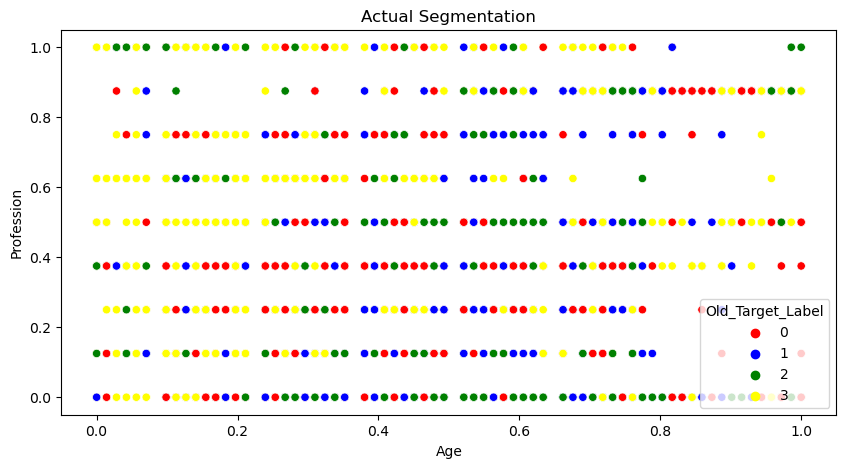

In [122]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=X_train_scaled_new['Age'],y=X_train_scaled_new['Profession'],
                hue=X_train_scaled_new['Old_Target_Label'],
                palette=['Red','Blue','Green','Yellow'])
plt.title("Actual Segmentation")
plt.show()

This **scatter plot**, titled **"Actual Segmentation,"** visualizes the relationship between **Age** and **Profession**, with data points color-coded by segmentation labels.

### **Key Insights**
- Data points are distributed across various **ages and professions**, showing **clear clusters** based on segmentation labels.
- Some **professions** seem to have a **higher concentration** of specific segmentation labels.
- Age variation plays a role in segmentation, with certain age groups tending to cluster together.

### **Why This Matters**
This scatter plot helps **visually segment populations** based on age and profession, which is useful for **market analysis, customer segmentation, or workforce distribution studies**.

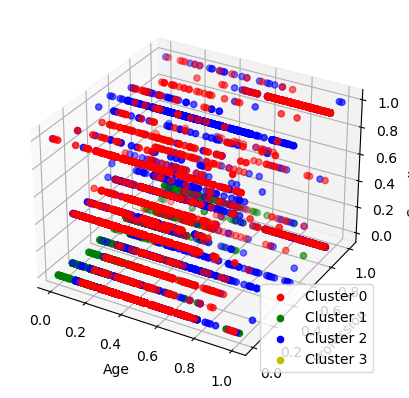

In [123]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b','y']
for cluster in range(4):
    ax.scatter(X_train_scaled_new[X_train_scaled_new['New_Target_Label'] == cluster]['Age'],
               X_train_scaled_new[X_train_scaled_new['New_Target_Label'] == cluster]['Profession'],
               X_train_scaled_new[X_train_scaled_new['New_Target_Label'] == cluster]['Spending_Score'],
               c=colors[cluster], label=f'Cluster {cluster}')

ax.set_xlabel('Age')
ax.set_ylabel('Profession')
ax.set_zlabel('Spending_Score')
plt.legend()
plt.show()

This **3D scatter plot** visualizes data points categorized into **four different clusters**, helping to understand their distribution in a three-dimensional space.

### **Key Insights**
1. **Clusters are spread across the 3D space**, showing distinctions in **Age and other unnamed variables**.
2. Some clusters **appear more densely packed**, indicating closely related data points.
3. Other clusters **spread out more**, suggesting greater variation within those groups.
4. The visualization helps identify **patterns, separation, and potential relationships** between age and other factors.


## **Predict on test Data**

In [125]:
test_pred = model.predict(X_test_scaled)

In [126]:
X_test_scaled_new = X_test_scaled.copy()

In [127]:
X_test_scaled_new['Old_Target_Label'] = y_test
X_test_scaled_new['New_Target_Label'] = test_pred

## **Silhouette Score Check performance**

In [129]:
from sklearn.metrics import silhouette_score

In [130]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_train_scaled)

C:\Users\prate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=4, random_state=42)

In [131]:
train_pred = kmeans.predict(X_train_scaled)

## **Silhouette Score For train Data**

In [133]:
silhouette_avg = silhouette_score(X_train_scaled, train_pred)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.298872961452178


## **Silhouette Score For Test Data**

In [135]:
test_pred = kmeans.predict(X_test_scaled)

# Calculate the silhouette score for Train data
silhouette_avg = silhouette_score(X_test_scaled, test_pred)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.3006645812606343


## *Visualization**

In [137]:
def silhouette_visualizer(data,model):
    visualizer=SilhouetteVisualizer(model,colors="yellowbrick")
    visualizer.fit(data)

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

def plotseg(data, labels, feature_names):
    plt.figure(figsize=(10, 6))

    scatter = plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', s=50)

    legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
    plt.gca().add_artist(legend1)

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])

    plt.title("Customer Segmentation based on K-Means Clustering")

    plt.show()

## **Age and Spending Score**

C:\Users\prate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


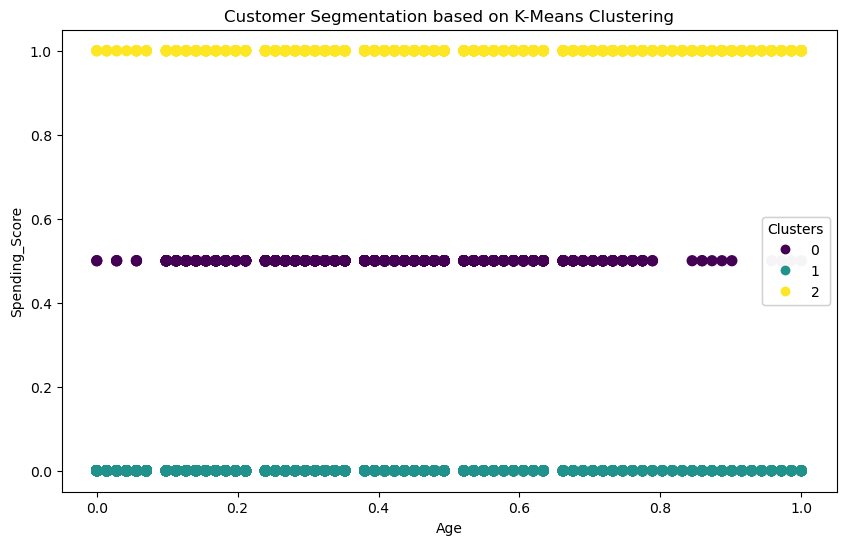

In [140]:
clus = X_train_scaled.loc[:, ["Age", "Spending_Score"]].values  # Age and Spending Score
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
Y = kmeans.fit_predict(clus)
plotseg(clus, Y, ["Age", "Spending_Score"])

This **scatter plot**, titled **"Customer Segmentation based on K-Means Clustering,"** visually represents how customers are grouped based on **Age** and **Spending Score**.

### **Key Insights**
- The **K-Means clustering algorithm** has effectively segmented customers into **three groups** based on their spending habits.
- Customers with **low spending scores (0.0, teal)** form a distinct cluster.
- Customers with **medium spending scores (0.5, purple)** form another separate cluster.
- Customers with **high spending scores (1.0, yellow)** make up the final cluster.
- The clear horizontal grouping suggests spending behavior is a **primary factor in customer segmentation**, with age playing a secondary role.

### **Insights**
This analysis helps businesses **identify different customer types**, allowing for **tailored marketing strategies**. For example:
- **Low spenders** may benefit from promotions or discounts.
- **Medium spenders** may require personalized recommendations.
- **High spenders** might be targeted with exclusive offers or loyalty programs.


## **Family size and profession**

In [142]:
clus1 = train.loc[:,["Family_Size","Profession"]].values

In [143]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
Y = kmeans.fit_predict(clus1)

C:\Users\prate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


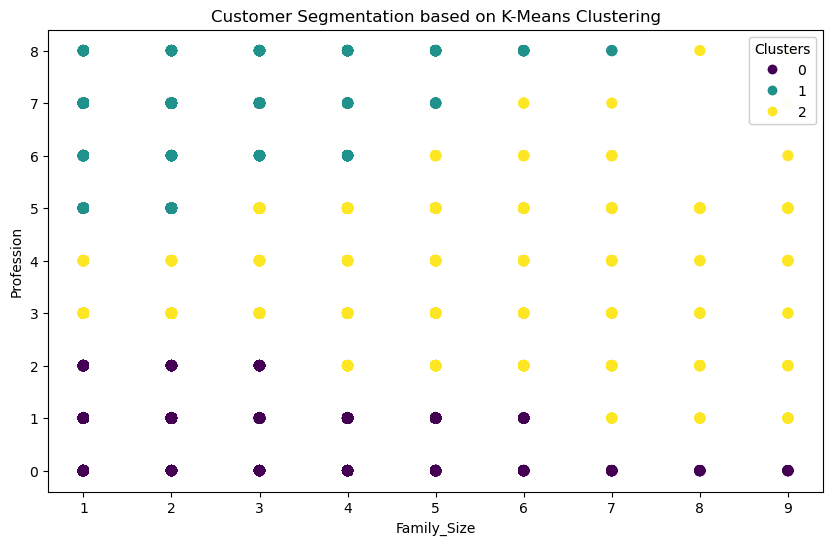

In [144]:
plotseg(clus1, Y, ["Family_Size","Profession"])
plt.show()

This **scatter plot**, titled **"Customer Segmentation based on K-Means Clustering,"** visualizes how customers are grouped based on **Family Size** (x-axis) and **Profession** (y-axis).


### **Key Insights**
- **Cluster 0 (Purple)**: Customers in this group appear to have **a mix of professions**, but their **family sizes seem more concentrated in a specific range**.
- **Cluster 1 (Yellow)**: This cluster consists of customers with **more variation in family size and profession**, indicating diverse segmentation.
- **Cluster 2 (Teal)**: Customers in this group are **more densely populated** within certain professions and family sizes, suggesting common characteristics.